In [3]:

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


df = pd.read_csv("/content/sample_data/healthcare_dataset.csv")


df = df.drop("patient_id", axis=1)

X = df.drop("diabetes", axis=1)
y = df["diabetes"]


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


model = LogisticRegression()
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

In [4]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.9091666666666667
Confusion Matrix:
 [[1091    0]
 [ 109    0]]
Classification Report:
               precision    recall  f1-score   support

           0       0.91      1.00      0.95      1091
           1       0.00      0.00      0.00       109

    accuracy                           0.91      1200
   macro avg       0.45      0.50      0.48      1200
weighted avg       0.83      0.91      0.87      1200



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [5]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Build model
nn_model = Sequential()

# Input + Hidden layers
nn_model.add(Dense(16, activation='relu', input_shape=(X_train.shape[1],)))
nn_model.add(Dense(8, activation='relu'))

# Output layer
nn_model.add(Dense(1, activation='sigmoid'))

# Compile
nn_model.compile(optimizer='adam',
                 loss='binary_crossentropy',
                 metrics=['accuracy'])

# Train
history = nn_model.fit(X_train, y_train,
                       epochs=50,
                       batch_size=16,
                       validation_split=0.2)

Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


240/240 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6844 - loss: 0.6165 - val_accuracy: 0.9062 - val_loss: 0.3438
Epoch 2/50
240/240 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9107 - loss: 0.3057 - val_accuracy: 0.9062 - val_loss: 0.3012
Epoch 3/50
240/240 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9107 - loss: 0.2886 - val_accuracy: 0.9062 - val_loss: 0.2917
Epoch 4/50
240/240 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9107 - loss: 0.2848 - val_accuracy: 0.9062 - val_loss: 0.2889
Epoch 5/50
240/240 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9107 - loss: 0.2833 - val_accuracy: 0.9062 - val_loss: 0.2878
Epoch 6/50
240/240 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9107 - loss: 0.2822 - val_accuracy: 0.9062 - val_loss: 0.2871
Epoch 7/50
240/240 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9107 - loss: 0.2813 - val_accuracy: 0.9062 - val_loss: 0.2864
Epoch 8/50
240/240 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9107 - loss: 0.2806 - val_accuracy: 0.9062 - val_

In [6]:
loss, accuracy = nn_model.evaluate(X_test, y_test)
print("Neural Network Accuracy:", accuracy)

38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9092 - loss: 0.2844
Neural Network Accuracy: 0.909166693687439


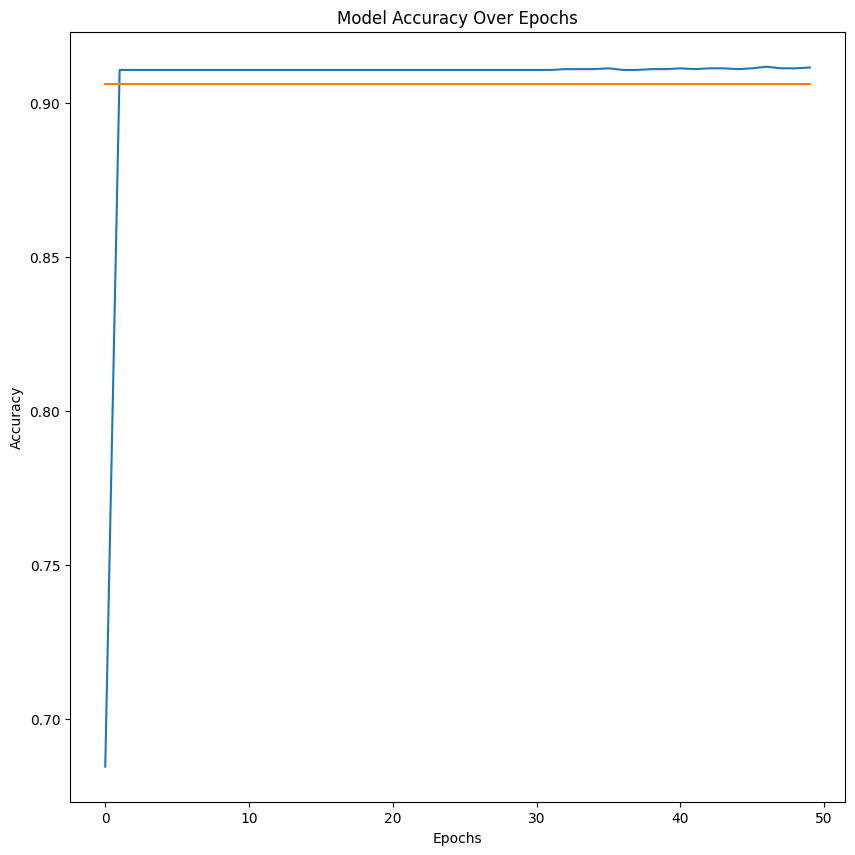

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 10))

sns.lineplot(x=range(len(history.history['accuracy'])),
             y=history.history['accuracy'])
sns.lineplot(x=range(len(history.history['val_accuracy'])),
             y=history.history['val_accuracy'])

plt.title('Model Accuracy Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')

plt.show()

plt.figure(figsize=(10, 10))
sns.histplot(df['val_accuracy'] , bins = 30)
plt.title('Model Accuracy Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.show()

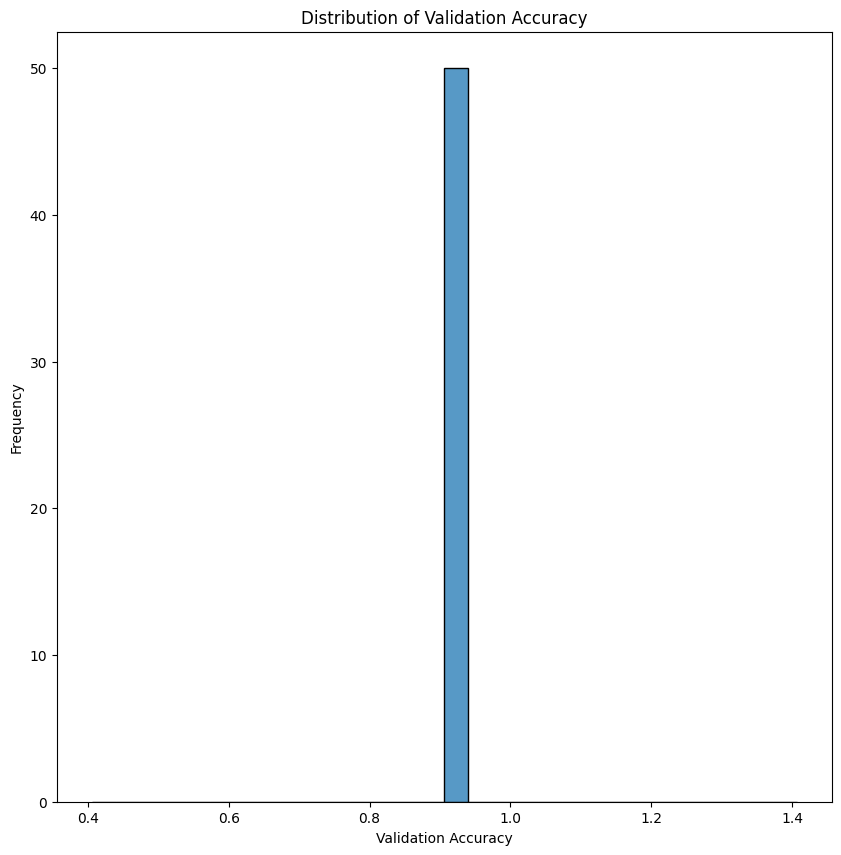

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 10))
sns.histplot(history.history['val_accuracy'] , bins = 30)
plt.title('Distribution of Validation Accuracy')
plt.xlabel('Validation Accuracy')
plt.ylabel('Frequency')
plt.show()